 # Characterization of manifolds in activation space.

 This notebook measures the quality of learned representations in LLM embedding space
 by dimensionality, smoothness and topology preservation.

In [ ]:
# Notebook setup
%cd /home/can/feature_zoo/
%load_ext autoreload
%autoreload 2

/home/can/feature_zoo


In [ ]:
# Initialize Experiment config (defines dataset, model, sae)

# Choose one

# override = ["llm=llama3.1-8b-base-layer15", "data=integers100"]
override = ["llm=llama3.1-8b-base-layer15", "data=years100"]
# override = ["llm=gpt2-layer6", "data=colors101"]
# override = ["llm=gpt2-layer6", "data=integers100"]
# override = ["llm=gpt2-layer6", "data=integers1000"]
# override = ["llm=gpt2-layer6", "data=integers1000step5"]
# override = ["llm=llama3.1-8b-base-layer15", "data=integers1000step5"]
# override = ["llm=llama3.1-8b-base-layer15", "data=years100"]
# override = ["llm=llama3.1-8b-base-layer15", "data=integers500"]
# override = ["llm=llama3.1-8b-base-layer15", "data=integers1000"]
# override = ["llm=llama3.1-8b-base-layer15", "data=days7"]
# override = ["llm=llama3.1-8b-base-layer15", "data=months12"]
# override = ["llm=llama3.1-8b-base-layer15", "data=colors101"]
# override = ["llm=llama3.1-8b-base-layer15", "data=colors101_lch"]
# override = ["llm=llama3.1-8b-base-layer15", "data=colors195_lch"]
# override = ["llm=llama3.1-8b-base-layer15", "data=emotions200"]
# override = ["llm=llama3.1-8b-base-embedding", "data=integers100", "exp=sum"]
# override = ["llm=olmo3-32b-base-layer32", "data=integers100"]
# override = ["llm=gpt2-layer6", "data=years100"]
# override = ["llm=gpt2-layer6", "data=colors6"]
# override = ["llm=gpt2-embedding", "data=integers100"]

In [ ]:
# Imports

from src.config import load_config
from src.cache_llm import load_short_trajectory_acts
from src.random_baseline import ensure_random_baseline_exists
import torch as th
import numpy as np
import matplotlib.pyplot as plt

def to_numpy(t: th.Tensor) -> np.ndarray:
    return t.detach().cpu().float().numpy()

def load_concept_labels(cfg):
    with open(f"data/texts/{cfg.filter.data}.txt") as f:
        lines = [line.strip() for line in f.readlines()]
    return lines

/home/can/feature_zoo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Cache data for both original and random baselines

def load_experiment_data(override):
    th.cuda.empty_cache()

    cfg = load_config(overrides=override)
    model_name = cfg.llm.name
    data_name = cfg.data.name

    print(f"Loading {model_name} - {data_name} (original)...")
    original_dict = load_short_trajectory_acts(cfg, force_recompute=False)

    print(f"Loading {model_name} - random baseline...")
    random_cfg = ensure_random_baseline_exists(cfg)
    random_dict = load_short_trajectory_acts(random_cfg, force_recompute=False)

    def process_return_dict(return_dict):
        if isinstance(return_dict["llm_BCD"], th.Tensor):
            llm_BCD = to_numpy(return_dict["llm_BCD"])
            input_ids_BT = return_dict["input_ids_BT"].cpu() if isinstance(return_dict["input_ids_BT"], th.Tensor) else return_dict["input_ids_BT"]
        else:
            llm_BCD = return_dict["llm_BCD"]
            input_ids_BT = return_dict["input_ids_BT"]
        return {
            "elements_C": return_dict["elements_C"],
            "labels_b": return_dict["labels_b"],
            "texts_b": return_dict["texts_b"],
            "input_ids_BT": input_ids_BT,
            "llm_BCD": llm_BCD,
        }

    experiment_data = {
        "original": process_return_dict(original_dict),
        "random": process_return_dict(random_dict),
        "data_name": data_name,
    }

    del original_dict, random_dict
    th.cuda.empty_cache()

    print(f"{model_name} original llm_BCD shape: {experiment_data['original']['llm_BCD'].shape}")
    print(f"{model_name} random llm_BCD shape: {experiment_data['random']['llm_BCD'].shape}")
    return experiment_data, model_name, data_name

experiment_data, model_name, data_name = load_experiment_data(override)

Loading llama3.1-8b-base-layer15 - years100 (original)...


/home/can/feature_zoo/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Loading llama3.1-8b-base-layer15 - random baseline...
llama3.1-8b-base-layer15 original llm_BCD shape: (100, 100, 4096)
llama3.1-8b-base-layer15 random llm_BCD shape: (100, 100, 4096)


 # Effective dimensionality

 ## PCA
 SVD on the full dataset can take long. Don't worry we will only do this once!

In [ ]:
import einops

def compute_svd(experiment_data):
    llm_og_BCD = experiment_data["original"]["llm_BCD"]
    llm_rd_BCD = experiment_data["random"]["llm_BCD"]

    # Center
    llm_og_BCD = llm_og_BCD - np.mean(llm_og_BCD, axis=-1, keepdims=True)
    llm_rd_BCD = llm_rd_BCD - np.mean(llm_rd_BCD, axis=-1, keepdims=True)

    # Reshape b = B x C
    llm_og_bD = einops.rearrange(llm_og_BCD, "B C D -> (B C) D")
    llm_rd_bD = einops.rearrange(llm_rd_BCD, "B C D -> (B C) D")

    # SVD on centered data is equal to PCA
    U_og_bD, S_og_D, Vh_og_DD = np.linalg.svd(llm_og_bD, full_matrices=False)
    U_rd_bD, S_rd_D, Vh_rd_DD = np.linalg.svd(llm_rd_bD, full_matrices=False)

    return U_og_bD, S_og_D, Vh_og_DD, U_rd_bD, S_rd_D, Vh_rd_DD

U_og_bD, S_og_D, Vh_og_DD, U_rd_bD, S_rd_D, Vh_rd_DD = compute_svd(experiment_data)
B, C, D = experiment_data["original"]["llm_BCD"].shape
# U_og_BCD = einops.rearrange(U_og_bD, "(B C) R -> B C R", B=B, C=C)
# U_rd_BCD = einops.rearrange(U_rd_bD, "(B C) R -> B C R", B=B, C=C)

In [ ]:
def compute_relative_variance(S_og_D, S_rd_D):
    rel_var_og = S_og_D**2 / np.sum(S_og_D**2)
    rel_var_rd = S_rd_D**2 / np.sum(S_rd_D**2)
    cum_var_og = np.cumsum(rel_var_og)
    cum_var_rd = np.cumsum(rel_var_rd)
    return rel_var_og, rel_var_rd, cum_var_og, cum_var_rd

rel_var_og, rel_var_rd, cum_var_og, cum_var_rd = compute_relative_variance(S_og_D, S_rd_D)

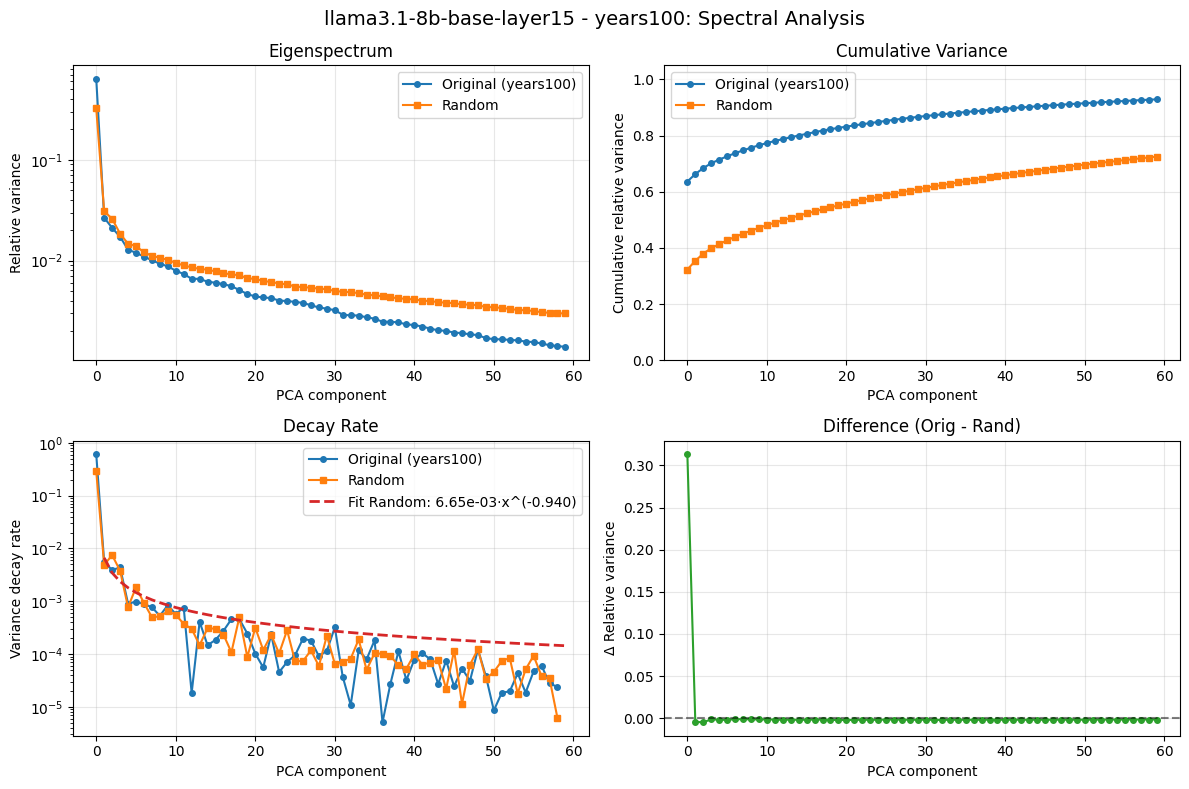

In [ ]:
def plot_spectral_analysis(rel_var_og, rel_var_rd, cum_var_og, cum_var_rd, model_name, data_name, comp_max=60):
    x = np.arange(comp_max)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"{model_name} - {data_name}: Spectral Analysis", fontsize=14)

    # Relative variance
    axes[0, 0].semilogy(x, rel_var_og[:comp_max], 'o-', c='tab:blue', markersize=4, label=f'Original ({data_name})')
    axes[0, 0].semilogy(x, rel_var_rd[:comp_max], 's-', c='tab:orange', markersize=4, label='Random')
    axes[0, 0].set_xlabel("PCA component")
    axes[0, 0].set_ylabel("Relative variance")
    axes[0, 0].set_title("Eigenspectrum")
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Cumulative relative variance
    axes[0, 1].plot(x, cum_var_og[:comp_max], 'o-', c='tab:blue', markersize=4, label=f'Original ({data_name})')
    axes[0, 1].plot(x, cum_var_rd[:comp_max], 's-', c='tab:orange', markersize=4, label='Random')
    axes[0, 1].set_xlabel("PCA component")
    axes[0, 1].set_ylabel("Cumulative relative variance")
    axes[0, 1].set_title("Cumulative Variance")
    axes[0, 1].set_ylim(0, 1.05)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Decay rate (consecutive difference in relative variance)
    decay_og = rel_var_og[:-1] - rel_var_og[1:]
    decay_rd = rel_var_rd[:-1] - rel_var_rd[1:]

    # Fit power law to random decay: f(x) = a * x^(-b)
    from scipy.optimize import curve_fit
    def power_law(x, a, b):
        return a * x ** (-b)
    x_fit = np.arange(1, comp_max)  # start at 1 to avoid 0^(-b)
    popt, _ = curve_fit(power_law, x_fit, decay_rd[1:comp_max], p0=[decay_rd[1], 1.0], maxfev=10000)
    a_fit, b_fit = popt

    axes[1, 0].semilogy(x[:-1], decay_og[:comp_max-1], 'o-', c='tab:blue', markersize=4, label=f'Original ({data_name})')
    axes[1, 0].semilogy(x[:-1], decay_rd[:comp_max-1], 's-', c='tab:orange', markersize=4, label='Random')
    axes[1, 0].semilogy(x_fit, power_law(x_fit, *popt), '--', c='tab:red', linewidth=2,
                         label=f'Fit Random: {a_fit:.2e}·x^(-{b_fit:.3f})')
    axes[1, 0].set_xlabel("PCA component")
    axes[1, 0].set_ylabel("Variance decay rate")
    axes[1, 0].set_title("Decay Rate")
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Difference (original - random)
    diff = rel_var_og[:comp_max] - rel_var_rd[:comp_max]
    axes[1, 1].plot(x, diff, 'o-', c='tab:green', markersize=4)
    axes[1, 1].axhline(0, color='k', linestyle='--', alpha=0.5)
    axes[1, 1].set_xlabel("PCA component")
    axes[1, 1].set_ylabel("Δ Relative variance")
    axes[1, 1].set_title("Difference (Orig - Rand)")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_spectral_analysis(rel_var_og, rel_var_rd, cum_var_og, cum_var_rd, model_name, data_name)

 ## Tortuosity (DM — Distance Metric)

In [ ]:
# Tortuosity

def _path_length(points_CD):
    """Total Euclidean path length along consecutive points."""
    diffs_CD = np.diff(points_CD, axis=0)
    return np.sum(np.linalg.norm(diffs_CD, axis=1))

def tortuosity_dm(points_CD):
    """Distance Metric: ratio of path length to chord length."""
    chord = np.linalg.norm(points_CD[-1] - points_CD[0])
    if chord < 1e-10:
        return float('inf')
    return _path_length(points_CD) / chord

def _tortuosity_per_template_BR(llm_BCD):
    """Compute DM tortuosity per template at each PCA truncation rank.

    Returns shape (B, R) where R is the number of truncation ranks.
    """
    llm_BCD = llm_BCD - np.mean(llm_BCD, axis=-1, keepdims=True)
    B, C, D = llm_BCD.shape
    n_components = min(C, D)
    dm_BR = np.empty((B, n_components))
    for b in range(B):
        llm_CD = llm_BCD[b]
        U_CD, S_D, _ = np.linalg.svd(llm_CD, full_matrices=False)
        for k in range(1, n_components + 1):
            truncated_Ck = U_CD[:, :k] * S_D[:k]
            dm_BR[b, k - 1] = tortuosity_dm(truncated_Ck)
    return dm_BR

def compute_tortuosity_over_rank(experiment_data):
    """Compute per-template DM tortuosity for original and random data."""
    orig_dm_BR = _tortuosity_per_template_BR(experiment_data["original"]["llm_BCD"])
    rand_dm_BR = _tortuosity_per_template_BR(experiment_data["random"]["llm_BCD"])
    n_components = orig_dm_BR.shape[1]
    ranks_R = np.arange(1, n_components + 1)
    return ranks_R, orig_dm_BR, rand_dm_BR

def find_convergence_start(tau, N=10, eps=0.1):
    """Find first rank r where tau remains stable for N consecutive steps.

    Criterion: max absolute change over window [r, r+N] < eps.
    """
    for r in range(len(tau) - N):
        window_changes = [abs(tau[i + 1] - tau[i]) for i in range(r, r + N)]
        if max(window_changes) < eps:
            return r
    return None

ranks_R, orig_dm_BR, rand_dm_BR = compute_tortuosity_over_rank(experiment_data)

orig_mean_R = np.mean(orig_dm_BR, axis=0)
conv_rank = find_convergence_start(orig_mean_R, N=50, eps=0.5)
print(f"Convergence rank: {ranks_R[conv_rank] if conv_rank is not None else 'not found'}")

Convergence rank: 21


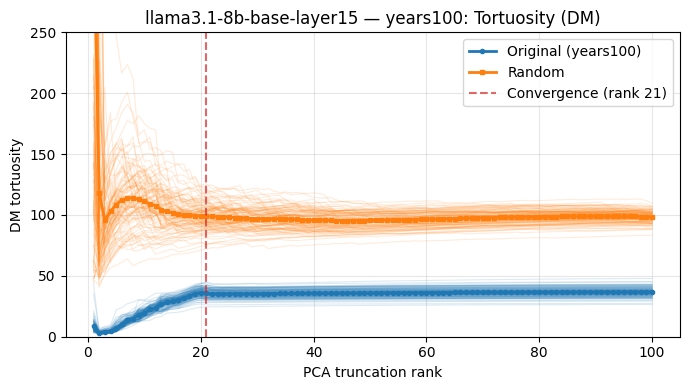

In [ ]:
# Plot tortuosity

def plot_tortuosity(ranks_R, orig_dm_BR, rand_dm_BR, conv_rank, model_name, data_name, max_traces=1000):
    fig, ax = plt.subplots(figsize=(7, 4))

    rng = np.random.default_rng(42)

    # Individual template trajectories (faint, random subset))
    orig_idx = rng.choice(orig_dm_BR.shape[0], size=min(max_traces, orig_dm_BR.shape[0]), replace=False)
    rand_idx = rng.choice(rand_dm_BR.shape[0], size=min(max_traces, rand_dm_BR.shape[0]), replace=False)
    for b in orig_idx:
        ax.plot(ranks_R, orig_dm_BR[b], color='tab:blue', alpha=0.15, linewidth=0.8)
    for b in rand_idx:
        ax.plot(ranks_R, rand_dm_BR[b], color='tab:orange', alpha=0.15, linewidth=0.8)

    # Mean trajectories (bold)
    orig_mean_R = np.mean(orig_dm_BR, axis=0)
    rand_mean_R = np.mean(rand_dm_BR, axis=0)
    ax.plot(ranks_R, orig_mean_R, 'o-', markersize=3, color='tab:blue', linewidth=2, label=f"Original ({data_name})")
    ax.plot(ranks_R, rand_mean_R, 's-', markersize=3, color='tab:orange', linewidth=2, label="Random")

    if conv_rank is not None:
        ax.axvline(ranks_R[conv_rank], color='tab:red', linestyle='--', alpha=0.7,
                   label=f"Convergence (rank {ranks_R[conv_rank]})")

    ax.set_xlabel("PCA truncation rank")
    ax.set_ylabel("DM tortuosity")
    ax.set_title(f"{model_name} — {data_name}: Tortuosity (DM)")
    ax.set_ylim((0, 250))
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_tortuosity(ranks_R, orig_dm_BR, rand_dm_BR, conv_rank, model_name, data_name)

In [ ]:
# Truncate SVD to pre-convergence ranks for downstream analysis

assert conv_rank is not None, "Convergence rank not found — adjust conv_N/conv_eps or inspect tortuosity plot"
R = ranks_R[conv_rank]  # number of components to keep
print(f"Truncating to R={R} components")

U_og_bR = U_og_bD[:, :R]
S_og_R = S_og_D[:R]
Vh_og_RD = Vh_og_DD[:R, :]

U_rd_bR = U_rd_bD[:, :R]
S_rd_R = S_rd_D[:R]
Vh_rd_RD = Vh_rd_DD[:R, :]

U_og_BCR = einops.rearrange(U_og_bR, "(B C) R -> B C R", B=B, C=C)
U_rd_BCR = einops.rearrange(U_rd_bR, "(B C) R -> B C R", B=B, C=C)

Truncating to R=21 components


 ## Gram matrix condition number
 The condition number gives the ratio between the max and min entry of the gram matrix.
 Random should be evenly distributed, nonrandom structure should have some points closer than others thus higher condition number.
 To be robust against ultra low values, we'll take lam min, the rank that explains 99 percent variance.

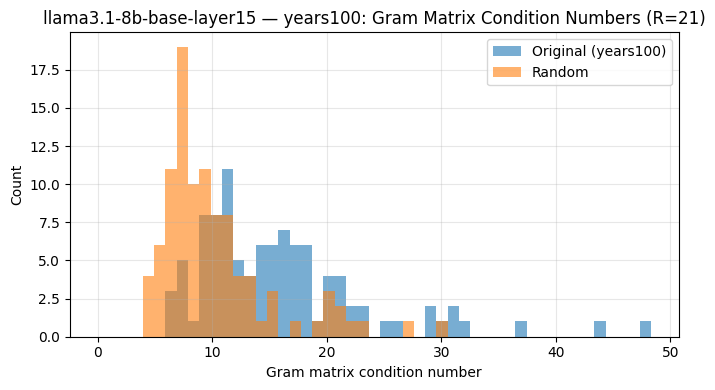


Original templates with condition number > 1e11 (2/100):
  [2] cond=4.83e+01: <|begin_of_text|>The cornerstone of the house bears the inscription {}
  [19] cond=4.34e+01: <|begin_of_text|>Archaeological surveys place the site's abandonment around {}


In [ ]:
# Gram matrix condition number: Intersection in embedding space

def effective_condition_number_B(U_BCR, energy_threshold=0.99):
    B, C, R = U_BCR.shape
    cond_B = np.empty(B)
    for b in range(B):
        G = U_BCR[b].T @ U_BCR[b]
        eigvals = np.linalg.eigvalsh(G)[::-1]  # descending
        eigvals = np.maximum(eigvals, 0)        # numerical safety
        cumulative = np.cumsum(eigvals) / np.sum(eigvals)
        r_eff = np.searchsorted(cumulative, energy_threshold) + 1
        cond_B[b] = eigvals[0] / eigvals[r_eff - 1]
    return cond_B

cond_og_B = effective_condition_number_B(U_og_BCR)
cond_rd_B = effective_condition_number_B(U_rd_BCR)

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, max(np.max(cond_og_B), np.max(cond_rd_B)), 50)
ax.hist(cond_og_B, bins=bins, alpha=0.6, color='tab:blue', label=f'Original ({data_name})')
ax.hist(cond_rd_B, bins=bins, alpha=0.6, color='tab:orange', label='Random')
ax.set_xlabel("Gram matrix condition number")
ax.set_ylabel("Count")
ax.set_title(f"{model_name} — {data_name}: Gram Matrix Condition Numbers (R={R})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


high_cond_thresh = 40
high_cond_mask = cond_og_B > high_cond_thresh
if np.any(high_cond_mask):
    print(f"\nOriginal templates with condition number > 1e11 ({np.sum(high_cond_mask)}/{B}):")
    texts_b = experiment_data["original"]["texts_b"]  # flat (B*C) despite key name
    labels_b = experiment_data["original"]["labels_b"]
    for idx in np.where(high_cond_mask)[0]:
        template = texts_b[idx * C].replace(labels_b[idx * C], "{}")
        print(f"  [{idx}] cond={cond_og_B[idx]:.2e}: {template}")
else:
    print(f"\nNo original templates with condition number > {high_cond_thresh}")

 ## Global Lipschitz constant (max consecutive-point distance) per template

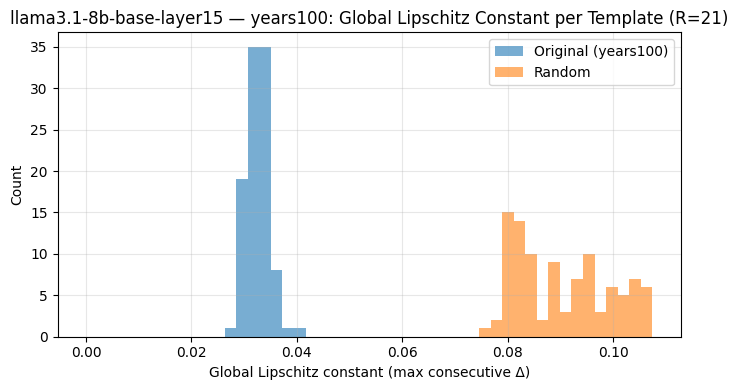

In [ ]:
def global_lipschitz_B(U_BCR):
    """Max Euclidean distance between consecutive points per template."""
    diffs_BCR = np.diff(U_BCR, axis=1)  # (B, C-1, R)
    norms_BC = np.linalg.norm(diffs_BCR, axis=2)  # (B, C-1)
    return np.max(norms_BC, axis=1)  # (B,)

lip_og_B = global_lipschitz_B(U_og_BCR)
lip_rd_B = global_lipschitz_B(U_rd_BCR)

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, max(np.max(lip_og_B), np.max(lip_rd_B)), 50)
ax.hist(lip_og_B, bins=bins, alpha=0.6, color='tab:blue', label=f'Original ({data_name})')
ax.hist(lip_rd_B, bins=bins, alpha=0.6, color='tab:orange', label='Random')
ax.set_xlabel("Global Lipschitz constant (max consecutive Δ)")
ax.set_ylabel("Count")
ax.set_title(f"{model_name} — {data_name}: Global Lipschitz Constant per Template (R={R})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 # Local Smoothness

 ## Discrete Jacobian norm along trajectory
 Plot the Euclidean norm of consecutive-point differences (discrete Jacobian)
 per template. Faint individual traces + bold mean, for original vs random.

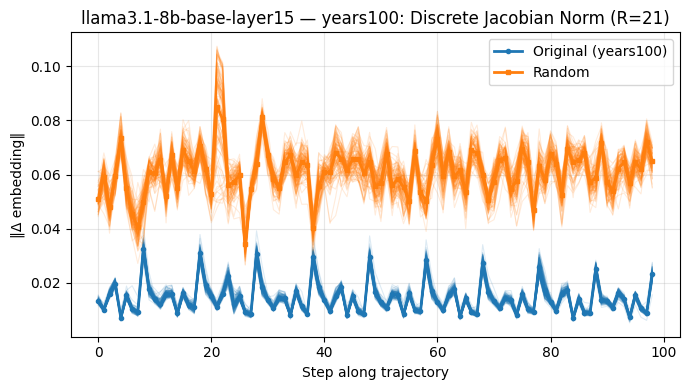

In [ ]:
def discrete_jacobian_norms_BC(U_BCR):
    """Euclidean norm of consecutive-point differences per template.

    Returns shape (B, C-1).
    """
    diffs_BCR = np.diff(U_BCR, axis=1)  # (B, C-1, R)
    return np.linalg.norm(diffs_BCR, axis=2)  # (B, C-1)

def plot_discrete_jacobian(og_norms_BC, rd_norms_BC, model_name, data_name, max_traces=1000):
    C_minus_1 = og_norms_BC.shape[1]
    x = np.arange(C_minus_1)

    fig, ax = plt.subplots(figsize=(7, 4))
    rng = np.random.default_rng(42)

    # Individual traces (faint)
    orig_idx = rng.choice(og_norms_BC.shape[0], size=min(max_traces, og_norms_BC.shape[0]), replace=False)
    rand_idx = rng.choice(rd_norms_BC.shape[0], size=min(max_traces, rd_norms_BC.shape[0]), replace=False)
    for b in orig_idx:
        ax.plot(x, og_norms_BC[b], color='tab:blue', alpha=0.15, linewidth=0.8)
    for b in rand_idx:
        ax.plot(x, rd_norms_BC[b], color='tab:orange', alpha=0.15, linewidth=0.8)

    # Mean trajectories (bold)
    og_mean_C = np.mean(og_norms_BC, axis=0)
    rd_mean_C = np.mean(rd_norms_BC, axis=0)
    ax.plot(x, og_mean_C, 'o-', markersize=3, color='tab:blue', linewidth=2, label=f"Original ({data_name})")
    ax.plot(x, rd_mean_C, 's-', markersize=3, color='tab:orange', linewidth=2, label="Random")

    ax.set_xlabel("Step along trajectory")
    ax.set_ylabel("‖Δ embedding‖")
    ax.set_title(f"{model_name} — {data_name}: Discrete Jacobian Norm (R={R})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

og_norms_BC = discrete_jacobian_norms_BC(U_og_BCR)
rd_norms_BC = discrete_jacobian_norms_BC(U_rd_BCR)
plot_discrete_jacobian(og_norms_BC, rd_norms_BC, model_name, data_name)

 ## Local PCA along trajectory
 Characterize local smoothness by fitting PCA in a sliding window along each
 trajectory. Two signals:
 1. **Tangent plane rotation**: max principal angle between consecutive local
    tangent planes (large → abrupt direction change).
 2. **Local explained variance**: fraction of local variance captured by the
    top `m` components (high → locally low-dimensional / smooth).

In [ ]:
def local_pca_along_trajectory(U_CR, k, m):
    """Fit local PCA in a symmetric window of size k around each trajectory point.

    Args:
        U_CR: trajectory points, shape (C, R)
        k: window size (will be clamped to C)
        m: number of top components to keep

    Returns:
        eigvals_Cm: top m eigenvalues at each point, shape (C, m)
        tangent_CmR: top m eigenvectors at each point, shape (C, m, R)
    """
    C, R = U_CR.shape
    k = min(k, C)
    half = k // 2
    eigvals_Cm = np.empty((C, m))
    tangent_CmR = np.empty((C, m, R))

    for i in range(C):
        lo = max(0, i - half)
        hi = min(C, i + half + 1)
        # Ensure we always take k points when possible
        if hi - lo < k:
            if lo == 0:
                hi = min(C, lo + k)
            else:
                lo = max(0, hi - k)
        window_wR = U_CR[lo:hi]  # (w, R) where w <= k
        window_wR = window_wR - window_wR.mean(axis=0, keepdims=True)
        _, S_R, Vh_RR = np.linalg.svd(window_wR, full_matrices=False)
        # Eigenvalues of covariance ∝ S^2
        eigvals_Cm[i] = S_R[:m] ** 2
        tangent_CmR[i] = Vh_RR[:m]

    return eigvals_Cm, tangent_CmR


def principal_angles_between_planes(V1_mR, V2_mR):
    """Compute principal angles between two subspaces.

    Args:
        V1_mR, V2_mR: orthonormal bases, shape (m, R)

    Returns:
        angles_m: principal angles in radians, shape (m,)
    """
    M_mm = V1_mR @ V2_mR.T  # (m, m)
    _, sigmas_m, _ = np.linalg.svd(M_mm)
    # Clamp for numerical safety before arccos
    sigmas_m = np.clip(sigmas_m, -1.0, 1.0)
    return np.arccos(sigmas_m)


def local_tangent_rotation_BC(U_BCR, k, m):
    """Max principal angle between consecutive local tangent planes per template.

    Returns shape (B, C-1).
    """
    B, C, R = U_BCR.shape
    rotation_BC = np.empty((B, C - 1))
    for b in range(B):
        _, tangent_CmR = local_pca_along_trajectory(U_BCR[b], k, m)
        for i in range(C - 1):
            angles_m = principal_angles_between_planes(tangent_CmR[i], tangent_CmR[i + 1])
            rotation_BC[b, i] = np.max(angles_m)
    return rotation_BC


def local_explained_variance_BC(U_BCR, k, m):
    """Fraction of local variance explained by top m components at each point.

    Returns shape (B, C).
    """
    B, C, R = U_BCR.shape
    m_all = min(min(k, C), R)  # max eigenvalues SVD can return
    expvar_BC = np.empty((B, C))
    for b in range(B):
        eigvals_Call, _ = local_pca_along_trajectory(U_BCR[b], k, m_all)
        top_m_C = eigvals_Call[:, :m].sum(axis=1)
        total_C = eigvals_Call.sum(axis=1)
        expvar_BC[b] = top_m_C / np.maximum(total_C, 1e-30)
    return expvar_BC

In [ ]:
# Compute local PCA metrics

k_window = min(11, C)
m_tangent = 3

og_rotation_BC = local_tangent_rotation_BC(U_og_BCR, k_window, m_tangent)
rd_rotation_BC = local_tangent_rotation_BC(U_rd_BCR, k_window, m_tangent)

og_expvar_BC = local_explained_variance_BC(U_og_BCR, k_window, m_tangent)
rd_expvar_BC = local_explained_variance_BC(U_rd_BCR, k_window, m_tangent)

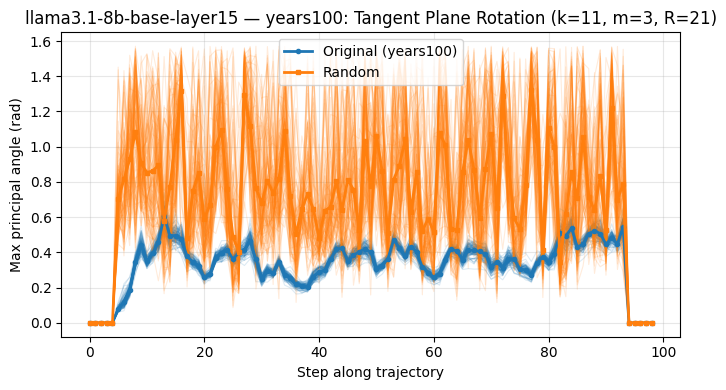

In [ ]:
# Plot 1 — Tangent plane rotation

def plot_tangent_rotation(og_rotation_BC, rd_rotation_BC, model_name, data_name, k, m, max_traces=1000):
    C_minus_1 = og_rotation_BC.shape[1]
    x = np.arange(C_minus_1)

    fig, ax = plt.subplots(figsize=(7, 4))
    rng = np.random.default_rng(42)

    # Individual traces (faint)
    orig_idx = rng.choice(og_rotation_BC.shape[0], size=min(max_traces, og_rotation_BC.shape[0]), replace=False)
    rand_idx = rng.choice(rd_rotation_BC.shape[0], size=min(max_traces, rd_rotation_BC.shape[0]), replace=False)
    for b in orig_idx:
        ax.plot(x, og_rotation_BC[b], color='tab:blue', alpha=0.15, linewidth=0.8)
    for b in rand_idx:
        ax.plot(x, rd_rotation_BC[b], color='tab:orange', alpha=0.15, linewidth=0.8)

    # Mean trajectories (bold)
    og_mean = np.mean(og_rotation_BC, axis=0)
    rd_mean = np.mean(rd_rotation_BC, axis=0)
    ax.plot(x, og_mean, 'o-', markersize=3, color='tab:blue', linewidth=2, label=f"Original ({data_name})")
    ax.plot(x, rd_mean, 's-', markersize=3, color='tab:orange', linewidth=2, label="Random")

    ax.set_xlabel("Step along trajectory")
    ax.set_ylabel("Max principal angle (rad)")
    ax.set_title(f"{model_name} — {data_name}: Tangent Plane Rotation (k={k}, m={m}, R={R})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_tangent_rotation(og_rotation_BC, rd_rotation_BC, model_name, data_name, k_window, m_tangent)

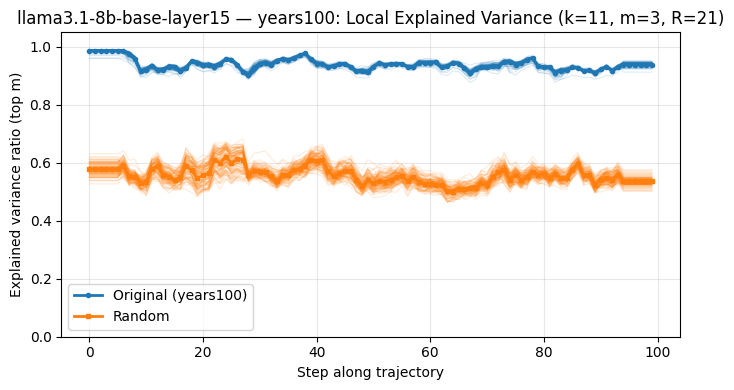

In [ ]:
# Plot 2 — Local explained variance ratio

def plot_local_explained_variance(og_expvar_BC, rd_expvar_BC, model_name, data_name, k, m, max_traces=1000):
    C_pts = og_expvar_BC.shape[1]
    x = np.arange(C_pts)

    fig, ax = plt.subplots(figsize=(7, 4))
    rng = np.random.default_rng(42)

    # Individual traces (faint)
    orig_idx = rng.choice(og_expvar_BC.shape[0], size=min(max_traces, og_expvar_BC.shape[0]), replace=False)
    rand_idx = rng.choice(rd_expvar_BC.shape[0], size=min(max_traces, rd_expvar_BC.shape[0]), replace=False)
    for b in orig_idx:
        ax.plot(x, og_expvar_BC[b], color='tab:blue', alpha=0.15, linewidth=0.8)
    for b in rand_idx:
        ax.plot(x, rd_expvar_BC[b], color='tab:orange', alpha=0.15, linewidth=0.8)

    # Mean trajectories (bold)
    og_mean = np.mean(og_expvar_BC, axis=0)
    rd_mean = np.mean(rd_expvar_BC, axis=0)
    ax.plot(x, og_mean, 'o-', markersize=3, color='tab:blue', linewidth=2, label=f"Original ({data_name})")
    ax.plot(x, rd_mean, 's-', markersize=3, color='tab:orange', linewidth=2, label="Random")

    ax.set_xlabel("Step along trajectory")
    ax.set_ylabel("Explained variance ratio (top m)")
    ax.set_title(f"{model_name} — {data_name}: Local Explained Variance (k={k}, m={m}, R={R})")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_local_explained_variance(og_expvar_BC, rd_expvar_BC, model_name, data_name, k_window, m_tangent)

 # Basis Fit Complexity
 For each PCA component of the centroid trajectory, find the minimum complexity
 (across multiple basis families) needed to achieve R² ≥ 0.95.

In [ ]:
# Fitting functions for basis fit complexity analysis

import pywt
from scipy.interpolate import make_lsq_spline


def r2_score(y_true_C, y_pred_C):
    """Standard R² (coefficient of determination)."""
    ss_res = np.sum((y_true_C - y_pred_C) ** 2)
    ss_tot = np.sum((y_true_C - np.mean(y_true_C)) ** 2)
    if ss_tot < 1e-30:
        return 1.0
    return 1.0 - ss_res / ss_tot


def fit_legendre(u_C, y_C, max_degree=30, r2_thresh=0.95):
    """Fit Legendre polynomials with increasing degree.

    Returns (min_degree, r2) achieving the threshold, or (max_degree, best_r2).
    """
    # Rescale u_C from [0, 1] to [-1, 1] for Legendre domain
    u_leg_C = 2.0 * u_C - 1.0
    for deg in range(1, max_degree + 1):
        coeffs = np.polynomial.legendre.legfit(u_leg_C, y_C, deg)
        y_pred_C = np.polynomial.legendre.legval(u_leg_C, coeffs)
        r2 = r2_score(y_C, y_pred_C)
        if r2 >= r2_thresh:
            return deg, r2
    return max_degree, r2


def fit_fourier(u_C, y_C, max_harmonics=50, r2_thresh=0.95):
    """Fit Fourier basis with increasing number of harmonics.

    Returns (min_harmonics, r2) achieving the threshold, or (max_harmonics, best_r2).
    """
    C = len(u_C)
    # Precompute full design matrix: [1, cos(2π·1·u), sin(2π·1·u), ...]
    max_cols = 2 * max_harmonics + 1
    design_CM = np.ones((C, max_cols))
    for h in range(1, max_harmonics + 1):
        design_CM[:, 2 * h - 1] = np.cos(2 * np.pi * h * u_C)
        design_CM[:, 2 * h] = np.sin(2 * np.pi * h * u_C)

    for M in range(1, max_harmonics + 1):
        ncols = 2 * M + 1
        X_Cn = design_CM[:, :ncols]
        coeffs, _, _, _ = np.linalg.lstsq(X_Cn, y_C, rcond=None)
        y_pred_C = X_Cn @ coeffs
        r2 = r2_score(y_C, y_pred_C)
        if r2 >= r2_thresh:
            return M, r2
    return max_harmonics, r2


def fit_bspline(u_C, y_C, n_interior_knots, r2_thresh=0.95):
    """Fit cubic B-spline with a fixed number of interior knots.

    Returns (n_interior_knots, r2).
    """
    k = 3  # cubic
    interior = np.linspace(0, 1, n_interior_knots + 2)[1:-1]
    knots = np.concatenate([
        np.zeros(k + 1),
        interior,
        np.ones(k + 1),
    ])
    # make_lsq_spline requires sorted u_C
    sort_idx = np.argsort(u_C)
    u_sorted_C = u_C[sort_idx]
    y_sorted_C = y_C[sort_idx]
    # Clamp endpoints slightly inside to avoid knot boundary issues
    u_sorted_C = np.clip(u_sorted_C, 1e-10, 1.0 - 1e-10)
    spline = make_lsq_spline(u_sorted_C, y_sorted_C, knots, k=k)
    y_pred_C = np.empty_like(y_C)
    y_pred_C[sort_idx] = spline(u_sorted_C)
    r2 = r2_score(y_C, y_pred_C)
    return n_interior_knots, r2


def fit_bspline_sweep(u_C, y_C, max_knots=50, r2_thresh=0.95):
    """Fit cubic B-spline with increasing interior knot count.

    Sweeps from 1 to max_knots interior knots, returning the minimum count
    achieving the R² threshold.

    Returns (min_knots, r2) achieving the threshold, or (max_knots, best_r2).
    """
    best_r2 = -np.inf
    for n_k in range(1, max_knots + 1):
        _, r2 = fit_bspline(u_C, y_C, n_interior_knots=n_k, r2_thresh=r2_thresh)
        best_r2 = max(best_r2, r2)
        if r2 >= r2_thresh:
            return n_k, r2
    return max_knots, best_r2


def fit_wavelet(u_C, y_C, r2_thresh=0.95):
    """Fit wavelet basis by retaining top-N coefficients.

    Returns (min_N, r2) achieving the threshold, or (total_coeffs, best_r2).
    """
    coeffs_list = pywt.wavedec(y_C, "db4")
    # Flatten all coefficients
    all_coeffs = np.concatenate([c.ravel() for c in coeffs_list])
    n_total = len(all_coeffs)

    # Sort by absolute value descending
    sorted_idx = np.argsort(np.abs(all_coeffs))[::-1]

    # Reconstruct coefficient structure shapes
    shapes = [c.shape for c in coeffs_list]
    boundaries = np.cumsum([0] + [c.size for c in coeffs_list])

    for N in range(1, n_total + 1):
        # Zero out all but top-N
        sparse = np.zeros_like(all_coeffs)
        sparse[sorted_idx[:N]] = all_coeffs[sorted_idx[:N]]
        # Rebuild coefficient list
        rebuilt = []
        for i, shape in enumerate(shapes):
            rebuilt.append(sparse[boundaries[i]:boundaries[i + 1]].reshape(shape))
        y_pred = pywt.waverec(rebuilt, "db4")
        # waverec can produce array slightly longer than input
        y_pred_C = y_pred[: len(y_C)]
        r2 = r2_score(y_C, y_pred_C)
        if r2 >= r2_thresh:
            return N, r2
    return n_total, r2

In [ ]:
# Sweep all methods per PCA component

def compute_basis_complexity_per_component(centroid_CR, max_components=15, r2_thresh=0.95):
    """Compute basis fit complexity for each PCA component of the centroid trajectory.

    Args:
        centroid_CR: shape (C, R) — mean over B of U_BCR
        max_components: max number of PCA components to analyze
        r2_thresh: R² threshold for "good enough" fit

    Returns:
        dict with keys = method names, values = list of (complexity, r2) per component
    """
    C, R_total = centroid_CR.shape
    n_comp = min(R_total, max_components)
    u_C = np.linspace(0, 1, C)

    methods = {
        "Legendre": lambda y: fit_legendre(u_C, y, max_degree=30, r2_thresh=r2_thresh),
        "Fourier": lambda y: fit_fourier(u_C, y, max_harmonics=50, r2_thresh=r2_thresh),
        "B-spline": lambda y: fit_bspline_sweep(u_C, y, max_knots=50, r2_thresh=r2_thresh),
        "Wavelet": lambda y: fit_wavelet(u_C, y, r2_thresh=r2_thresh),
    }

    results = {name: [] for name in methods}
    for j in range(n_comp):
        y_C = centroid_CR[:, j]
        for name, fn in methods.items():
            complexity, r2 = fn(y_C)
            results[name].append((complexity, r2))
    return results

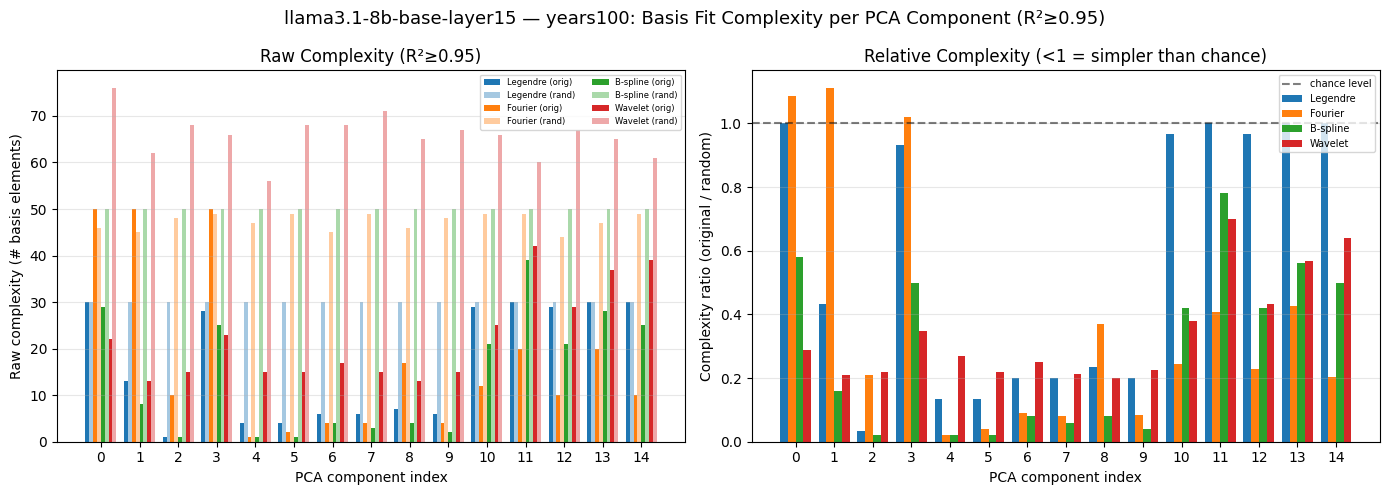

In [ ]:
# Normalization + plotting

def plot_basis_complexity(centroid_og_CR, centroid_rd_CR, model_name, data_name,
                          max_components=15, r2_thresh=0.95):
    """Plot basis fit complexity per PCA component.

    Two panels:
    - Left: raw complexity (number of basis elements) for original and random.
    - Right: complexity ratio (original / random) per method. Values < 1 mean
      the real manifold is simpler than chance.
    """

    results_og = compute_basis_complexity_per_component(centroid_og_CR, max_components, r2_thresh)
    results_rd = compute_basis_complexity_per_component(centroid_rd_CR, max_components, r2_thresh)

    method_names = list(results_og.keys())
    n_methods = len(method_names)
    n_comp = len(results_og[method_names[0]])
    colors = plt.cm.tab10(np.arange(n_methods))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: raw complexity for original vs random (grouped bars)
    ax = axes[0]
    x = np.arange(n_comp)
    bar_width = 0.8 / (n_methods * 2)
    for i, name in enumerate(method_names):
        og_raw = [results_og[name][j][0] for j in range(n_comp)]
        rd_raw = [results_rd[name][j][0] for j in range(n_comp)]
        offset_og = (2 * i) * bar_width
        offset_rd = (2 * i + 1) * bar_width
        ax.bar(x + offset_og, og_raw, bar_width, color=colors[i], label=f"{name} (orig)")
        ax.bar(x + offset_rd, rd_raw, bar_width, color=colors[i], alpha=0.4, label=f"{name} (rand)")
    ax.set_xlabel("PCA component index")
    ax.set_ylabel("Raw complexity (# basis elements)")
    ax.set_title(f"Raw Complexity (R²≥{r2_thresh})")
    ax.set_xticks(x + bar_width * (n_methods - 0.5))
    ax.set_xticklabels([str(i) for i in range(n_comp)])
    ax.legend(fontsize=6, loc="upper right", ncol=2)
    ax.grid(True, alpha=0.3, axis="y")

    # Right panel: complexity ratio (original / random)
    ax = axes[1]
    bar_width = 0.8 / n_methods
    for i, name in enumerate(method_names):
        og_raw = np.array([results_og[name][j][0] for j in range(n_comp)], dtype=float)
        rd_raw = np.array([results_rd[name][j][0] for j in range(n_comp)], dtype=float)
        # Ratio: original / random (avoid division by zero)
        ratio = og_raw / np.maximum(rd_raw, 1.0)
        ax.bar(x + i * bar_width, ratio, bar_width, color=colors[i], label=name)

    ax.axhline(1.0, color='k', linestyle='--', alpha=0.5, label="chance level")
    ax.set_xlabel("PCA component index")
    ax.set_ylabel("Complexity ratio (original / random)")
    ax.set_title("Relative Complexity (<1 = simpler than chance)")
    ax.set_xticks(x + bar_width * (n_methods - 1) / 2)
    ax.set_xticklabels([str(i) for i in range(n_comp)])
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3, axis="y")

    fig.suptitle(
        f"{model_name} — {data_name}: Basis Fit Complexity per PCA Component (R²≥{r2_thresh})",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()


# Compute centroids: mean over templates (B dimension)
centroid_og_CR = np.mean(U_og_BCR, axis=0)  # (C, R)
centroid_rd_CR = np.mean(U_rd_BCR, axis=0)  # (C, R)

plot_basis_complexity(centroid_og_CR, centroid_rd_CR, model_name, data_name)